In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("yellow_tripdata_2026-01.parquet")


In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [7]:
print("Shape: ",df.shape)

Shape:  (3724889, 20)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [9]:
print("Missing Values")
df.isnull().sum()

Missing Values


VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [11]:
print("Perentage of missing value")
print(round((df.isnull().sum()/len(df))*100,2))

Perentage of missing value
VendorID                  0.00
tpep_pickup_datetime      0.00
tpep_dropoff_datetime     0.00
passenger_count          29.21
trip_distance             0.00
RatecodeID               29.21
store_and_fwd_flag       29.21
PULocationID              0.00
DOLocationID              0.00
payment_type              0.00
fare_amount               0.00
extra                     0.00
mta_tax                   0.00
tip_amount                0.00
tolls_amount              0.00
improvement_surcharge     0.00
total_amount              0.00
congestion_surcharge     29.21
Airport_fee              29.21
cbd_congestion_fee        0.00
dtype: float64


In [12]:
print("Column thats have null values")
df.columns[df.isnull().any()].tolist()

Column thats have null values


['passenger_count',
 'RatecodeID',
 'store_and_fwd_flag',
 'congestion_surcharge',
 'Airport_fee']

In [13]:
df=df.drop(columns=['RatecodeID',
 'store_and_fwd_flag',
 'congestion_surcharge',
 'Airport_fee'])
print("The unnessary columns are drop")

The unnessary columns are drop


In [14]:
print("Important columns")
df.columns

Important columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'cbd_congestion_fee'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   PULocationID           int32         
 6   DOLocationID           int32         
 7   payment_type           int64         
 8   fare_amount            float64       
 9   extra                  float64       
 10  mta_tax                float64       
 11  tip_amount             float64       
 12  tolls_amount           float64       
 13  improvement_surcharge  float64       
 14  total_amount           float64       
 15  cbd_congestion_fee     float64       
dtypes: datetime64[us](2), float64(10), int32(3), int64(1)
memory usage: 412.1 MB


In [16]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
cbd_congestion_fee             0
dtype: int64

In [17]:
df['passenger_count']

0          1.0
1          0.0
2          0.0
3          4.0
4          0.0
          ... 
3724884    NaN
3724885    NaN
3724886    NaN
3724887    NaN
3724888    NaN
Name: passenger_count, Length: 3724889, dtype: float64

In [21]:
df['passenger_count']=df['passenger_count'].fillna(df['passenger_count'].median())

In [22]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
cbd_congestion_fee       0
dtype: int64

In [23]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,0.75


In [24]:
df=df[df['trip_distance']>0]
df=df[df['fare_amount']>0]
df=df[df['tolls_amount']>0]
df=df[df['passenger_count']>0]

In [26]:
print("After removing invalid record the total data is ")
df.shape

After removing invalid record the total data is 


(231954, 16)

In [29]:
df['trip duration min']=(
    (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
    .dt.total_seconds() / 60).round(2)

In [31]:
df['trip duration min']

51         43.05
65         26.15
112        75.58
149        27.32
404        18.70
           ...  
3724743    26.18
3724761    12.63
3724766    43.72
3724796    16.13
3724824    25.95
Name: trip duration min, Length: 231954, dtype: float64

In [32]:
df['pickup hour']=df['tpep_pickup_datetime'].dt.hour
df['pickup day']=df['tpep_pickup_datetime'].dt.day
df['pickup_weekday']=df['tpep_pickup_datetime'].dt.weekday

In [33]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip duration min,pickup hour,pickup day,pickup_weekday
51,2,2026-01-01 00:01:27,2026-01-01 00:44:30,1.0,18.47,132,246,1,70.0,0.00,0.5,16.34,6.94,1.0,99.78,0.75,43.05,0,1,3
65,2,2026-01-01 00:51:26,2026-01-01 01:17:35,1.0,5.89,170,37,1,30.3,1.00,0.5,8.60,6.94,1.0,51.59,0.75,26.15,0,1,3
112,1,2026-01-01 00:32:16,2026-01-01 01:47:51,1.0,11.10,137,133,1,64.6,4.25,0.5,15.45,6.94,1.0,92.74,0.75,75.58,0,1,3
149,2,2026-01-01 00:00:22,2026-01-01 00:27:41,2.0,19.15,132,75,2,70.0,0.00,0.5,0.00,6.94,1.0,80.19,0.00,27.32,0,1,3
404,2,2026-01-01 00:31:18,2026-01-01 00:50:00,4.0,11.49,48,265,1,135.0,0.00,0.0,0.00,14.06,1.0,150.81,0.75,18.70,0,1,3


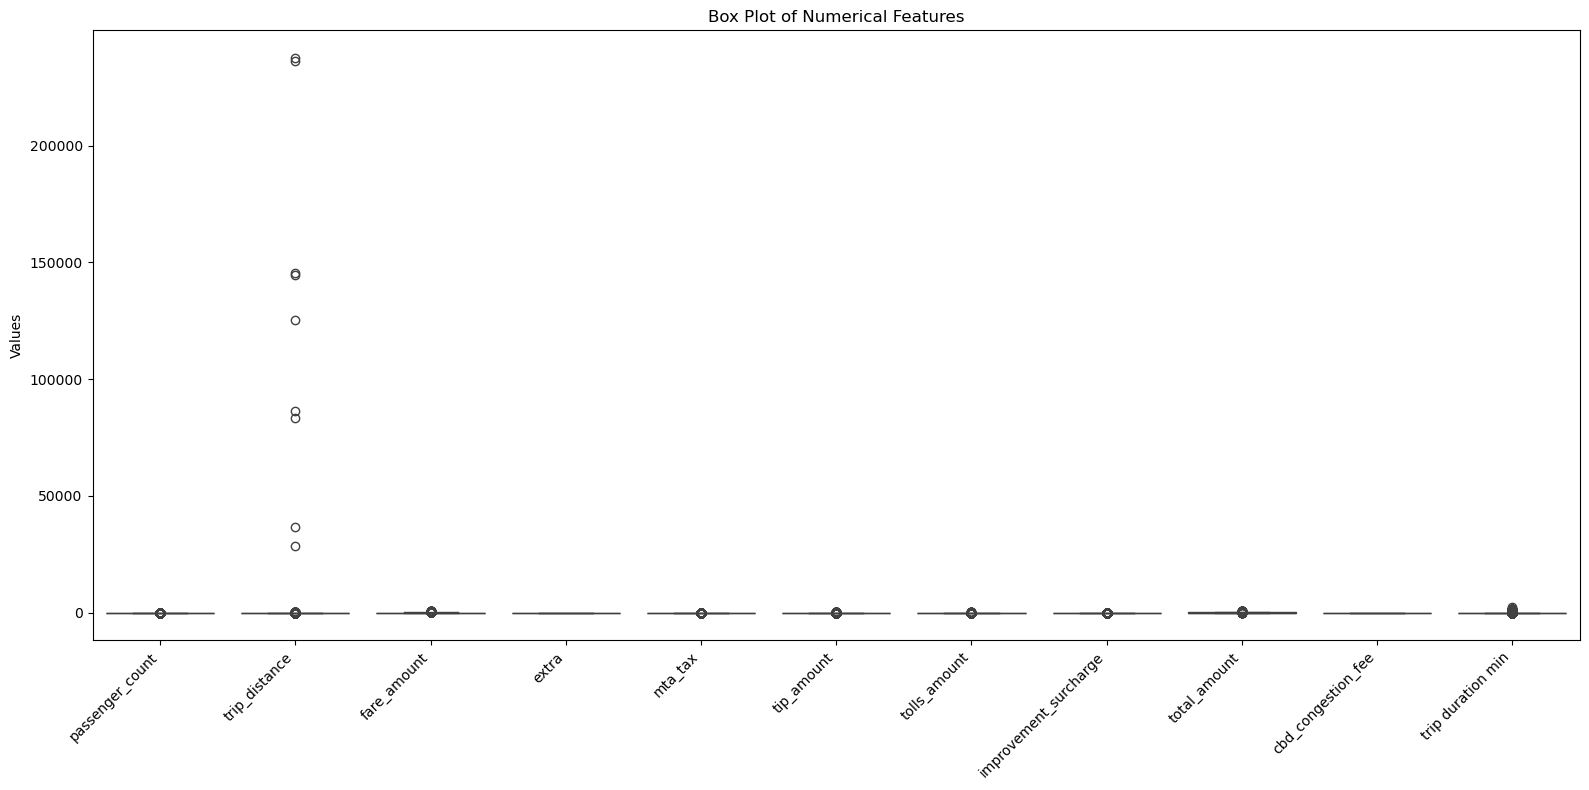

In [36]:
# Select meaningful continuous numeric columns
numeric_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'cbd_congestion_fee',
    'trip duration min'
]

# Create box plots
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of Numerical Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [37]:
q1=df['trip_distance'].quantile(0.25)
q3=df['trip_distance'].quantile(0.75)
print("Q1",q1,"Q3",q3)

Q1 8.75 Q3 17.5


In [38]:
IQR=q3-q1

In [39]:
upper_limit=q3+1.5*IQR
lower_limit=q1-1.5*IQR
print("Lower limit",lower_limit,"Upper limit",upper_limit)

Lower limit -4.375 Upper limit 30.625


In [40]:
df['trip_distance'] = df['trip_distance'].clip(
    lower=lower_limit,
    upper=upper_limit
)

<Axes: ylabel='trip_distance'>

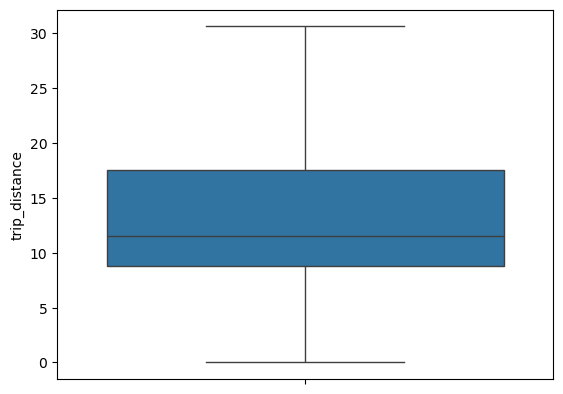

In [41]:
sns.boxplot(df['trip_distance'])

In [44]:
df["revenue_per_mile"] = round(df["total_amount"] / df["trip_distance"], 2)
df["revenue_per_minute"] = round(df["total_amount"] / df["trip duration min"], 2)
df["tip_percentage"] = round(df["tip_amount"] / df["fare_amount"], 2)

In [46]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,cbd_congestion_fee,trip duration min,pickup hour,pickup day,pickup_weekday,revenue_per_mile,revenue_per_minute,tip_percentage
count,231954.000000,231954,231954,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,...,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.000000,231954.00,231954.000000
mean,1.843266,2026-01-16 04:25:17.724639,2026-01-16 05:03:34.892258,1.270696,12.900998,143.427399,152.579451,0.902351,54.868653,2.423670,...,0.913310,78.020382,0.461574,38.286132,13.900463,15.584443,3.025708,31.898955,inf,0.147903
min,1.000000,2025-12-31 23:58:58,2026-01-01 00:03:35,1.000000,0.010000,1.000000,1.000000,0.000000,0.010000,-0.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00,0.000000
25%,2.000000,2026-01-08 16:10:22.750000,2026-01-08 17:04:09.500000,1.000000,8.750000,132.000000,100.000000,1.000000,38.000000,0.000000,...,1.000000,58.460000,0.000000,24.530000,10.000000,8.000000,1.000000,5.100000,1.71,0.000000
50%,2.000000,2026-01-15 18:54:34,2026-01-15 19:29:31,1.000000,11.480000,138.000000,145.000000,1.000000,50.600000,0.000000,...,1.000000,75.390000,0.750000,34.050000,15.000000,15.000000,3.000000,6.170000,2.20,0.170000
75%,2.000000,2026-01-23 09:24:36.750000,2026-01-23 10:07:25,1.000000,17.500000,162.000000,229.000000,1.000000,70.000000,5.000000,...,1.000000,97.097500,0.750000,47.080000,19.000000,23.000000,5.000000,7.540000,2.82,0.260000
max,7.000000,2026-01-31 23:59:56,2026-02-01 01:01:08,6.000000,30.625000,265.000000,265.000000,4.000000,899.000000,12.500000,...,1.000000,911.710000,0.750000,2344.720000,23.000000,31.000000,6.000000,18294.000000,inf,5.370000
std,0.670911,NaN,NaN,0.651881,5.685178,53.393141,72.495512,0.610278,25.820608,3.096282,...,0.280038,30.941861,0.364870,26.769095,5.887240,8.877874,1.886439,404.836927,NaN,0.136959


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 231954 entries, 51 to 3724824
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               231954 non-null  int32         
 1   tpep_pickup_datetime   231954 non-null  datetime64[us]
 2   tpep_dropoff_datetime  231954 non-null  datetime64[us]
 3   passenger_count        231954 non-null  float64       
 4   trip_distance          231954 non-null  float64       
 5   PULocationID           231954 non-null  int32         
 6   DOLocationID           231954 non-null  int32         
 7   payment_type           231954 non-null  int64         
 8   fare_amount            231954 non-null  float64       
 9   extra                  231954 non-null  float64       
 10  mta_tax                231954 non-null  float64       
 11  tip_amount             231954 non-null  float64       
 12  tolls_amount           231954 non-null  float64

In [48]:
df.to_csv("Cleaned_yellow_tripdata_2025-01.csv",index=False)

In [50]:
df.to_parquet("Cleaned_yellow_tripdata_2025-01.parquet", index=False)